In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import os
import re


In [2]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

from sklearn.metrics import accuracy_score

In [3]:
# Download necessary resources
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to C:\Users\AL-
[nltk_data]     MOSTAFA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\AL-
[nltk_data]     MOSTAFA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\AL-
[nltk_data]     MOSTAFA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\AL-
[nltk_data]     MOSTAFA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# EDA

In [4]:
df = pd.read_csv('F:/Projects/Project NLP ,LLMs/sentiment_analysis/data/raw/sentiment_data.csv')
df.head(10)

,Unnamed: 0,text,sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2
5,5,we’ve hounding bank adopt apple pay understand...,1
6,6,got apple pay south africa it’s widely accepted,2
7,7,need apple pay physical credit card,1
8,8,united states abundance retailers accept apple...,2
9,9,cambodia universal qr code system scan send mo...,1


In [5]:
df.tail()

,Unnamed: 0,text,sentiment
241140,241921,crores paid neerav modi recovered congress lea...,0
241141,241922,dear rss terrorist payal gawar modi killing pl...,0
241142,241923,cover interaction forum left,1
241143,241924,big project came india modi dream project happ...,1
241144,241925,ever listen like gurukul discipline maintained...,2


In [6]:
df.shape

(241145, 3)

In [7]:
df["sentiment"].value_counts()

sentiment
2    103059
1     82972
0     55114
Name: count, dtype: int64

In [9]:
# df["Time of Tweet"].value_counts()

In [10]:
df.duplicated().sum()

0

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(241145, 3)

In [13]:
df.head()

,Unnamed: 0,text,sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   text        240928 non-null  object
 2   sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


In [38]:
df.text.apply(lambda x: len(x))

0         231
1         113
2         114
3         328
4          93
         ... 
241140     79
241141    223
241142     28
241143     58
241144    158
Name: text, Length: 240928, dtype: int64

In [18]:
df.dropna(inplace=True)
df.isna().sum()

Unnamed: 0    0
text          0
sentiment     0
dtype: int64

# Preprocessing

In [19]:
import re  # For regex-based text cleaning
from nltk.tokenize import word_tokenize  # For splitting text into word tokens
from nltk.corpus import stopwords  # For loading common stop words
from nltk.stem import WordNetLemmatizer ,PorterStemmer

# Load English stop words into a set for faster lookup
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def preprocess_text(text):
    
    # Return empty string if the value is missing (NaN)
    if df.isna().sum().any():
        print("Warning: Missing values detected in the dataset. Consider handling them before tokenization.")
        
    
    # Convert input to string and lowercase it
    text = str(text).lower()
    
    # Remove URLs, mentions, and hashtags
    text = re.sub(r"http\S+|www\S+|@\w+|#\w+", " ", text)
    
    # Keep only English letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Tokenize the text into words
    tokens = word_tokenize(text)
    
    # Lemmatize each token
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    # tokens = [stemmer.stem(w) for w in tokens]


    # Remove common stop words
    tokens = [w for w in tokens if w not in stop_words]
    
    # Join tokens back into a cleaned sentence
    return " ".join(tokens)

# Apply preprocessing to the text column and create a new cleaned_text column
df["cleaned_text"] = df["text"].apply(preprocess_text)


In [20]:
from sklearn.model_selection import train_test_split

X = df["cleaned_text"].values

y = df[["sentiment"]].values


X_train_text, X_test_text, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
from sklearn.calibration import LabelEncoder

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train_raw)
y_test_enc = encoder.transform(y_test_raw)

g:\Anaconda\envs\gpu_env\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
g:\Anaconda\envs\gpu_env\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [22]:
# from sklearn.preprocessing import OneHotEncoder

# encoder = OneHotEncoder(sparse_output=  False)

# y_train_enc = encoder.fit_transform(y_train_raw)
# y_test_enc = encoder.transform(y_test_raw)  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenization and Padding
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train_text) 

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

max_len = max(len(seq) for seq in X_train_seq)

X_train_padded = pad_sequences(X_train_seq, padding='post', maxlen=max_len)
X_test_padded = pad_sequences(X_test_seq, padding='post', maxlen=max_len)

In [39]:
max_len

438

In [31]:
len(X_train_text[1].split()),X_train_text[1]

(24,
 'modi govt achievement terminates india status beneficiary developing country gsp regime plastic industry alone lose export gsp withdrawal likely affect india plastic export plexconcil')

In [32]:
X_test_seq[1]

[2070, 1, 2019, 563, 2026]

In [33]:
X_train_padded[1]

array([   1,   20,  138,    2, 1142, 2457, 1745,   23,  732, 4655, 1444,
        730,  603, 2745, 1196, 2488,    2, 4655, 2745,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [40]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
model.add(SimpleRNN(256,activation="tanh"))

model.add(Dense(1, activation="softmax"))

In [41]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [42]:
history = model.fit(X_train_padded ,
                    y_train_enc ,
                    epochs = 20 ,
                    validation_data=(X_test_padded,y_test_enc)
                    )

Epoch 1/20


g:\Anaconda\envs\gpu_env\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
g:\Anaconda\envs\gpu_env\Lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1425s 236ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 2/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1410s 234ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 3/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1391s 231ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 4/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1389s 231ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 5/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1500s 249ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 6/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1426s 237ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 7/20
6024/6024 ━━━━━━━━━━━━━━━━━━━━ 1413s 234ms/step - accuracy: 0.3432 - loss: 0.0000e+00 - val_accuracy: 0.3451 - val_loss: 0.0000e+00
Epoch 8/20

KeyboardInterrupt: 

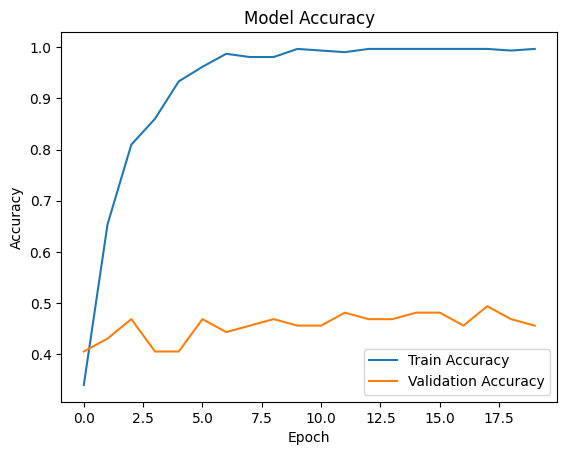

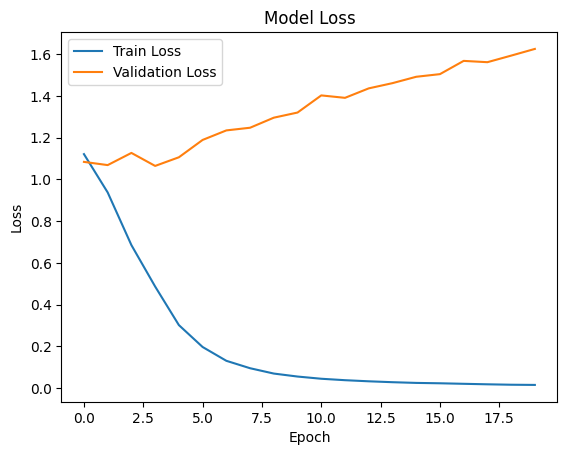

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.show()


# Loss Plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [ ]:
new_text = "I absolutely loved the movie but the ending was slow."
new_seq = tokenizer.texts_to_sequences([new_text])
new_padded = pad_sequences(new_seq, padding="pre", maxlen=max_len)
pred_probs = model.predict(new_padded)
pred_label = encoder.inverse_transform(pred_probs)
print(pred_label[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
['neutral']
